# Mean Listed Price by Genre

The Steam merchandising team wants to compare mean listed prices across eight major game genres and identify which genre has the highest average listed price.

## Load and prepare the data

Load the Steam dataset and prepare the listed price field for the genre comparison.

In [1]:
import pandas as pd


STEAM_PATH = "../../data/steam/steam.csv"

TARGET_GENRES = [
    "Action",
    "Adventure",
    "Casual",
    "Indie",
    "RPG",
    "Strategy",
    "Simulation",
    "Sports",
]


steam = pd.read_csv(STEAM_PATH)

steam["price"] = pd.to_numeric(
    steam["price"],
    errors="coerce",
)

## Select the requested genres

Restrict the analysis to the eight genre categories specified in the question.

In [2]:
genre_data = steam[
    steam["genres"].isin(TARGET_GENRES)
].copy()

## Calculate genre-level price statistics

Calculate the number of games, mean listed price, and median listed price for each genre.

In [3]:
genre_summary = (
    genre_data
    .groupby("genres")
    .agg(
        game_count=("genres", "size"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
    )
    .reindex(TARGET_GENRES)
    .reset_index(names="genre")
)

## Rank genres by mean price

Rank the genres by mean listed price and identify the genre with the highest average.

In [4]:
genre_ranking = (
    genre_summary
    .sort_values(
        "mean_price",
        ascending=False,
    )
    .reset_index(drop=True)
)

genre_ranking.index += 1
genre_ranking.index.name = "rank"


display_summary = genre_ranking.copy()

display_summary["mean_price"] = (
    display_summary["mean_price"]
    .map(lambda x: f"${x:.2f}")
)

display_summary["median_price"] = (
    display_summary["median_price"]
    .map(lambda x: f"${x:.2f}")
)


print("Mean price comparison by genre:")
print(display_summary.to_string())


highest = genre_ranking.iloc[0]

print("\nFinal result:")
print(
    "Genre with the highest average price:",
    highest["genre"],
)

print(
    "Highest average price:",
    f"${highest['mean_price']:.2f}",
)

Mean price comparison by genre:
           genre  game_count mean_price median_price
rank                                                
1         Sports          63     $13.80        $8.99
2            RPG         270     $11.97        $8.15
3     Simulation         328     $10.87        $6.99
4       Strategy         485     $10.41        $6.99
5         Action         843      $9.98        $6.99
6      Adventure         535      $8.73        $6.99
7         Casual         560      $4.68        $3.99
8          Indie         759      $3.97        $2.89

Final result:
Genre with the highest average price: Sports
Highest average price: $13.80


## Visualize genre coverage

Compare the number of games represented in each genre used in the price analysis.

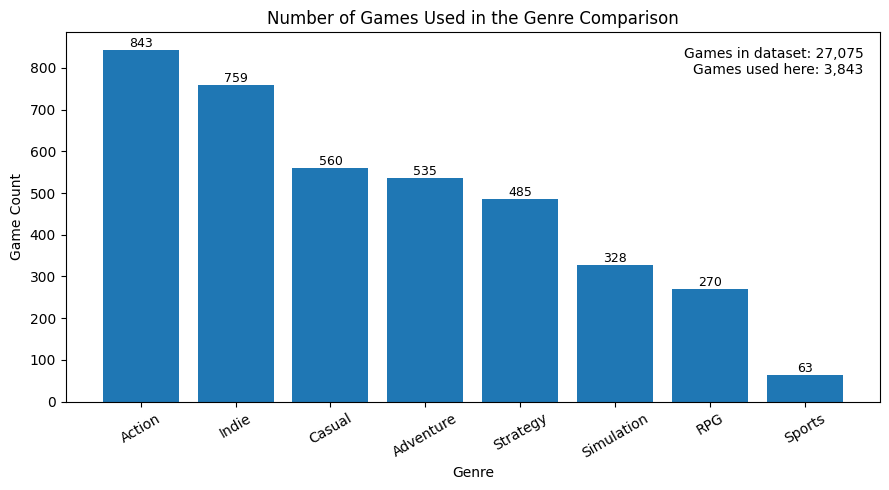

In [6]:
import matplotlib.pyplot as plt

plot_data = (
    genre_summary
    .sort_values(
        "game_count",
        ascending=False,
    )
)


fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    plot_data["genre"],
    plot_data["game_count"],
)


ax.set_title(
    "Number of Games Used in the Genre Comparison"
)

ax.set_xlabel(
    "Genre"
)

ax.set_ylabel(
    "Game Count"
)

ax.tick_params(
    axis="x",
    rotation=30,
)


for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.text(
    0.98,
    0.96,
    (
        f"Games in dataset: {len(steam):,}\n"
        f"Games used here: {len(genre_data):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
)


plt.tight_layout()
plt.show()

## Conclusion

Sports has the highest mean listed price among the eight genres analyzed, with an average price of $13.80.